In [1]:
import mbo_utilities as mbo
import matplotlib.pyplot as plt
import fastplotlib as fpl

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),Intel(R) Graphics (RPL-P),IntegratedGPU,Vulkan,Mesa 24.0.3-1pop1~1711635559~22.04~7a9f319
❗ limited,"llvmpipe (LLVM 15.0.7, 256 bits)",CPU,Vulkan,Mesa 24.0.3-1pop1~1711635559~22.04~7a9f319 (LLVM 15.0.7)
❌,Mesa Intel(R) Graphics (RPL-P),IntegratedGPU,OpenGL,4.6 (Core Profile) Mesa 24.2.8-1~bpo12+1pop1~1744225826~22.04~b077665


In [34]:
import numpy as np
from scipy.ndimage import fourier_shift
from skimage.registration import phase_cross_correlation
import tifffile
from pathlib import Path
from typing import Union

def _compute_offset_fft(frame: np.ndarray, upsample: int):
    pre = frame[::2, :]
    post = frame[1::2, :]
    m = min(pre.shape[0], post.shape[0])
    pre, post = pre[:m], post[:m]
    shift, _, _ = phase_cross_correlation(pre, post, upsample_factor=upsample)
    return shift[1]

def _apply_shift_fft2d(frame: np.ndarray, offset: float):
    out = frame.copy()
    rows = frame[1::2, :]
    f = np.fft.fftn(rows)
    fshift = fourier_shift(f, (0, -offset))
    rows_corr = np.fft.ifftn(fshift).real
    out[1::2, :] = rows_corr
    return out

def fix_scan_phase_fft_tiff(path: Union[str, Path], upsample: int = 10) -> np.ndarray:
    data = tifffile.imread(path)
    if data.ndim != 3:
        raise ValueError("Expected 3D T×Y×X TIFF")
    corrected = []
    for frame in data:
        off = _compute_offset_fft(frame, upsample)
        corrected.append(_apply_shift_fft2d(frame, off))
    return np.stack(corrected, axis=0)

In [35]:
raw = r"/home/flynn/lbm_data/raw"
files = mbo.get_files(raw)
files

['/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00004.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00002.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00010.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00008.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00005.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00001.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00000.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00009.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00003.tif',
 '/home/flynn/lbm_data/raw/mk301_03_01_2025_2roi_17p07hz_224x448px_2umpx_180mw_green_00006.tif',
 '/home/flynn/lbm_data/raw/mk3

In [28]:
scan = mbo.read_scan(raw)

In [29]:
mbo.save_as(scan, "/home/flynn/lbm_data/assembled", fix_phase=False)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/392 [00:00<?, ?it/s]

Time elapsed: 0 minutes 40 seconds.


In [11]:
tif = tifffile.imread(files[0])
tif.shape

(119, 14, 912, 224)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
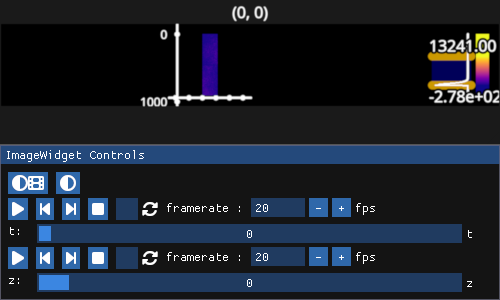

In [12]:
fpl.ImageWidget(tif).show()

## Scan-phase from assembled files

In [37]:
asmbled = r"/home/flynn/lbm_data/assembled"
files = mbo.get_files(asmbled)
files

['/home/flynn/lbm_data/assembled/plane_01.tif',
 '/home/flynn/lbm_data/assembled/plane_02.tif',
 '/home/flynn/lbm_data/assembled/plane_03.tif',
 '/home/flynn/lbm_data/assembled/plane_04.tif',
 '/home/flynn/lbm_data/assembled/plane_05.tif',
 '/home/flynn/lbm_data/assembled/plane_06.tif',
 '/home/flynn/lbm_data/assembled/plane_07.tif',
 '/home/flynn/lbm_data/assembled/plane_08.tif',
 '/home/flynn/lbm_data/assembled/plane_09.tif',
 '/home/flynn/lbm_data/assembled/plane_10.tif',
 '/home/flynn/lbm_data/assembled/plane_11.tif',
 '/home/flynn/lbm_data/assembled/plane_12.tif',
 '/home/flynn/lbm_data/assembled/plane_13.tif',
 '/home/flynn/lbm_data/assembled/plane_14.tif']

In [49]:
from pprint import PrettyPrinter

metadata = mbo.get_metadata(files[7])
PrettyPrinter(depth=2, compact=True).pprint(metadata) # don't show huge 'si' metadata

{'dims': ['time', 'width', 'height'],
 'dtype': 'int16',
 'fov': [448, 448],
 'fov_px': [224, 448],
 'frame_rate': 17.06701142272251,
 'ndim': 4,
 'nframes': 1437,
 'num_frames': 1437,
 'num_planes': 14,
 'num_rois': 2,
 'objective_resolution': 61,
 'pixel_resolution': [2.0, 2.0],
 'raw_frames': 381.0,
 'raw_height': 912,
 'raw_width': 224,
 'roi_height_px': 448,
 'roi_width_px': 224,
 'shape': [1437, 448, 448],
 'si': {'FrameData': {...}, 'RoiGroups': {...}, 'version': 4},
 'size': 1089672192,
 'tiff_pages': 5334,
 'trimmed': [0, 0, 0, 0]}


In [50]:
files[6]

'/home/flynn/lbm_data/assembled/plane_07.tif'

In [51]:
data = tifffile.imread(files[6])

In [52]:
upsample = 10

n_fixes = 0
n_notfixes = 0
corrected = []
for frame in data:
    off = _compute_offset_fft(frame, upsample)
    corrected.append(_apply_shift_fft2d(frame, -off))

out = np.stack(corrected, axis=0)

In [21]:
offset = mbo.return_scan_offset(data)
offset

-1

In [65]:
corr = mbo.fix_scan_phase(data, -offset)
corr.shape

(1437, 448, 448)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
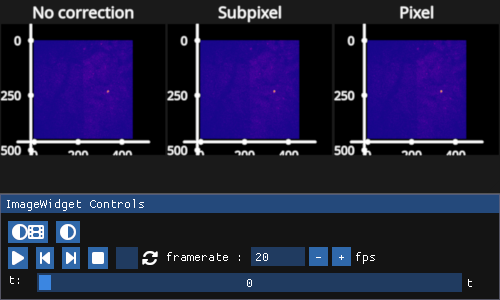

In [66]:
fpl.ImageWidget(
    data=[data, out, corr],
    names=["No correction", "Subpixel", "Pixel"],
    histogram_widget=False, 
    figure_shape=(1, 3)
).show()

In [22]:
out.shape

(1437, 448, 448)

In [24]:
tifffile.imwrite("/home/flynn/lbm_data/plane_12.tiff", out, metadata=metadata)

In [ ]:
import lbm_suite2p_python as lsp
import mbo_utilities as mbo
metadata = mbo.get_metadata("/home/flynn/lbm_data/plane_12.tiff")
metadata

In [ ]:
lsp.run_plane("/home/flynn/lbm_data/plane_12.tiff")

In [28]:
reg_f = mbo.get_files("/home/flynn/lbm_data/plane11/reg_tif", 'tif', 3)
reg_f

['/home/flynn/lbm_data/plane11/reg_tif/file00000_chan0.tif',
 '/home/flynn/lbm_data/plane11/reg_tif/file00500_chan0.tif',
 '/home/flynn/lbm_data/plane11/reg_tif/file001000_chan0.tif']

In [33]:
reg = np.concatenate([tifffile.imread(x) for x in reg_f])[:, 100:-100, 100:-100]
reg.shape

(1437, 248, 248)

In [ ]:
data = np.concatenate([imread(tif) for tif in files])

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
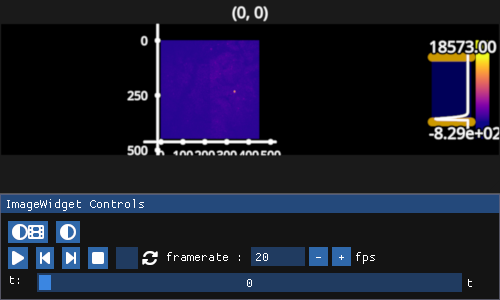

In [32]:
fpl.ImageWidget(reg).show()